<a href="https://colab.research.google.com/github/tharunkumarsurya/Cricket_analysis_Using_ML/blob/main/IPL_Cricket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
deliveries=pd.read_csv('/content/deliveries.csv')

In [3]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
match=pd.read_csv('/content/matches.csv')

In [5]:
match.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
deliveries.shape

(260920, 17)

In [7]:
match.shape

(1095, 20)

In [8]:
deliverie=deliveries.copy()

In [9]:
deliverie.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [10]:
matchs=match.copy()

In [11]:
matchs.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


IPL data analysis


In [12]:
deliverie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [13]:
matchs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [14]:
matchs.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [15]:
matchs.describe(include='all')

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
count,1.095000e+03,1095,1044,1095,1095,1090,1095,1095,1095,1095,1095,1090,1095,1076.000000,1092.000000,1092.000000,1095,21,1095,1095
unique,NaN,17,36,823,8,291,58,19,19,19,2,19,4,NaN,NaN,NaN,2,1,62,62
top,NaN,2013,Mumbai,2008-04-26,League,AB de Villiers,Eden Gardens,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,NaN,NaN,NaN,N,D/L,AK Chaudhary,S Ravi
freq,NaN,76,173,2,1029,25,77,135,138,143,704,144,578,NaN,NaN,NaN,1081,21,115,83
mean,9.048283e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.259294,165.684066,19.759341,NaN,NaN,NaN,NaN
std,3.677402e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.787444,33.427048,1.581108,NaN,NaN,NaN,NaN
min,3.359820e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,43.000000,5.000000,NaN,NaN,NaN,NaN
25%,5.483315e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,146.000000,20.000000,NaN,NaN,NaN,NaN
50%,9.809610e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,166.000000,20.000000,NaN,NaN,NaN,NaN
75%,1.254062e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,187.000000,20.000000,NaN,NaN,NaN,NaN


In [16]:
matchs.describe(include='object')


,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,super_over,method,umpire1,umpire2
count,1095,1044,1095,1095,1090,1095,1095,1095,1095,1095,1090,1095,1095,21,1095,1095
unique,17,36,823,8,291,58,19,19,19,2,19,4,2,1,62,62
top,2013,Mumbai,2008-04-26,League,AB de Villiers,Eden Gardens,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,N,D/L,AK Chaudhary,S Ravi
freq,76,173,2,1029,25,77,135,138,143,704,144,578,1081,21,115,83


In [17]:
deliverie.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [18]:
deliverie.describe(include='all')

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
count,2.609200e+05,260920.000000,260920,260920,260920.000000,260920.000000,260920,260920,260920,260920.000000,260920.000000,260920.000000,14125,260920.000000,12950,12950,9354
unique,NaN,NaN,19,19,NaN,NaN,673,530,663,NaN,NaN,NaN,5,NaN,629,10,607
top,NaN,NaN,Mumbai Indians,Mumbai Indians,NaN,NaN,V Kohli,R Ashwin,V Kohli,NaN,NaN,NaN,wides,NaN,RG Sharma,caught,MS Dhoni
freq,NaN,NaN,31437,31505,NaN,NaN,6236,4679,6067,NaN,NaN,NaN,8380,NaN,223,8063,220
mean,9.070665e+05,1.483531,NaN,NaN,9.197677,3.624486,NaN,NaN,NaN,1.265001,0.067806,1.332807,NaN,0.049632,NaN,NaN,NaN
std,3.679913e+05,0.502643,NaN,NaN,5.683484,1.814920,NaN,NaN,NaN,1.639298,0.343265,1.626416,NaN,0.217184,NaN,NaN,NaN
min,3.359820e+05,1.000000,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN
25%,5.483340e+05,1.000000,NaN,NaN,4.000000,2.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN
50%,9.809670e+05,1.000000,NaN,NaN,9.000000,4.000000,NaN,NaN,NaN,1.000000,0.000000,1.000000,NaN,0.000000,NaN,NaN,NaN
75%,1.254066e+06,2.000000,NaN,NaN,14.000000,5.000000,NaN,NaN,NaN,1.000000,0.000000,1.000000,NaN,0.000000,NaN,NaN,NaN


In [19]:
deliverie.describe(include='object')

,batting_team,bowling_team,batter,bowler,non_striker,extras_type,player_dismissed,dismissal_kind,fielder
count,260920,260920,260920,260920,260920,14125,12950,12950,9354
unique,19,19,673,530,663,5,629,10,607
top,Mumbai Indians,Mumbai Indians,V Kohli,R Ashwin,V Kohli,wides,RG Sharma,caught,MS Dhoni
freq,31437,31505,6236,4679,6067,8380,223,8063,220


DATA CLEANING


In [20]:
# drop rows with missing values in the 'winner' column

matchs = matchs.dropna(subset=['winner'])
print(matchs)

           id   season        city        date   match_type  player_of_match  \
0      335982  2007/08   Bangalore  2008-04-18       League      BB McCullum   
1      335983  2007/08  Chandigarh  2008-04-19       League       MEK Hussey   
2      335984  2007/08       Delhi  2008-04-19       League      MF Maharoof   
3      335985  2007/08      Mumbai  2008-04-20       League       MV Boucher   
4      335986  2007/08     Kolkata  2008-04-20       League        DJ Hussey   
...       ...      ...         ...         ...          ...              ...   
1090  1426307     2024   Hyderabad  2024-05-19       League  Abhishek Sharma   
1091  1426309     2024   Ahmedabad  2024-05-21  Qualifier 1         MA Starc   
1092  1426310     2024   Ahmedabad  2024-05-22   Eliminator         R Ashwin   
1093  1426311     2024     Chennai  2024-05-24  Qualifier 2    Shahbaz Ahmed   
1094  1426312     2024     Chennai  2024-05-26        Final         MA Starc   

                                       

In [21]:
# impute missing values in 'player_of_match'

matchs['player_of_match']=matchs['player_of_match'].fillna('Unknown')

In [22]:
#drop unwanted columns from the dataset

matchs.drop(['id','city','method'], axis=1, inplace=True)

In [23]:
import matplotlib.pyplot as plt

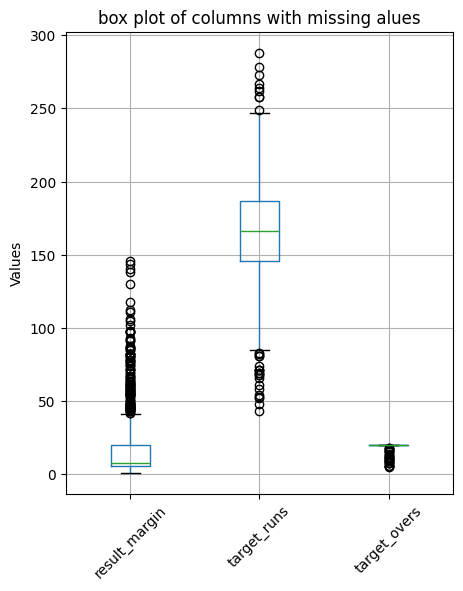

In [24]:
columns_to_handle_missing=['result_margin','target_runs','target_overs']


#plot box plots for rach columns

plt.figure(figsize=(5,6))
matchs[columns_to_handle_missing].boxplot()
plt.title("box plot of columns with missing alues")
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.show()

In [25]:
match['result_margin'].median()

8.0

In [26]:
matchs['result_margin']=matchs['result_margin'].fillna(matchs['result_margin'].median())

In [27]:
matchs['target_runs']=matchs['target_runs'].fillna(matchs['target_runs'].median())

In [28]:
matchs['target_overs']=matchs['target_overs'].fillna(matchs['target_overs'].median())

In [29]:
matchs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           1090 non-null   object 
 1   date             1090 non-null   object 
 2   match_type       1090 non-null   object 
 3   player_of_match  1090 non-null   object 
 4   venue            1090 non-null   object 
 5   team1            1090 non-null   object 
 6   team2            1090 non-null   object 
 7   toss_winner      1090 non-null   object 
 8   toss_decision    1090 non-null   object 
 9   winner           1090 non-null   object 
 10  result           1090 non-null   object 
 11  result_margin    1090 non-null   float64
 12  target_runs      1090 non-null   float64
 13  target_overs     1090 non-null   float64
 14  super_over       1090 non-null   object 
 15  umpire1          1090 non-null   object 
 16  umpire2          1090 non-null   object 
dtypes: float64(3), obje

In [30]:
matchs.nunique()

,0
season,17
date,821
match_type,8
player_of_match,291
venue,58
team1,19
team2,19
toss_winner,19
toss_decision,2
winner,19


Feature Engineering

In [31]:
matchs.head(3)

,season,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
0,2007/08,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
1,2007/08,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,MR Benson,SL Shastri
2,2007/08,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,Aleem Dar,GA Pratapkumar


In [32]:
matchs = match.copy()
matchs['dates'] = pd.to_datetime(matchs['date'])
matchs['year'] = matchs['dates'].dt.year
matchs['month'] = matchs['dates'].dt.month
matchs['day'] = matchs['dates'].dt.day
# Drop the original date column
matchs.drop('date', axis=1, inplace=True)

In [33]:
matchs.head(10)

,id,season,city,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,...,target_runs,target_overs,super_over,method,umpire1,umpire2,dates,year,month,day
0,335982,2007/08,Bangalore,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2008-04-18,2008,4,18
1,335983,2007/08,Chandigarh,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,241.0,20.0,N,NaN,MR Benson,SL Shastri,2008-04-19,2008,4,19
2,335984,2007/08,Delhi,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,2008-04-19,2008,4,19
3,335985,2007/08,Mumbai,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,166.0,20.0,N,NaN,SJ Davis,DJ Harper,2008-04-20,2008,4,20
4,335986,2007/08,Kolkata,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,111.0,20.0,N,NaN,BF Bowden,K Hariharan,2008-04-20,2008,4,20
5,335987,2007/08,Jaipur,League,SR Watson,Sawai Mansingh Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,bat,...,167.0,20.0,N,NaN,Aleem Dar,RB Tiffin,2008-04-21,2008,4,21
6,335988,2007/08,Hyderabad,League,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Delhi Daredevils,Deccan Chargers,bat,...,143.0,20.0,N,NaN,IL Howell,AM Saheba,2008-04-22,2008,4,22
7,335989,2007/08,Chennai,League,ML Hayden,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Mumbai Indians,Mumbai Indians,field,...,209.0,20.0,N,NaN,DJ Harper,GA Pratapkumar,2008-04-23,2008,4,23
8,335990,2007/08,Hyderabad,League,YK Pathan,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Rajasthan Royals,Rajasthan Royals,field,...,215.0,20.0,N,NaN,Asad Rauf,MR Benson,2008-04-24,2008,4,24
9,335991,2007/08,Chandigarh,League,KC Sangakkara,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,...,183.0,20.0,N,NaN,Aleem Dar,AM Saheba,2008-04-25,2008,4,25


In [34]:
matchs.tail(5)

,id,season,city,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,...,target_runs,target_overs,super_over,method,umpire1,umpire2,dates,year,month,day
1090,1426307,2024,Hyderabad,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,...,215.0,20.0,N,NaN,Nitin Menon,VK Sharma,2024-05-19,2024,5,19
1091,1426309,2024,Ahmedabad,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,...,160.0,20.0,N,NaN,AK Chaudhary,R Pandit,2024-05-21,2024,5,21
1092,1426310,2024,Ahmedabad,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,...,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar,2024-05-22,2024,5,22
1093,1426311,2024,Chennai,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,...,176.0,20.0,N,NaN,Nitin Menon,VK Sharma,2024-05-24,2024,5,24
1094,1426312,2024,Chennai,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,...,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon,2024-05-26,2024,5,26


In [35]:
# function to split season values

def split_season(season):
  if '/' in season:
    start, end = season.split('/')
    start = int(start)
    end = int('20'+ end) if len(end) ==2 else int(end)
  else:
    start =end = int(season)
  return start, end

In [36]:
#apply the function to create new columns


matchs[['season_start','season_end']]=matchs['season'].apply(lambda x: pd.Series(split_season(x)))

In [37]:
matchs.head(3)

,id,season,city,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,...,super_over,method,umpire1,umpire2,dates,year,month,day,season_start,season_end
0,335982,2007/08,Bangalore,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,N,NaN,Asad Rauf,RE Koertzen,2008-04-18,2008,4,18,2007,2008
1,335983,2007/08,Chandigarh,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,N,NaN,MR Benson,SL Shastri,2008-04-19,2008,4,19,2007,2008
2,335984,2007/08,Delhi,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,N,NaN,Aleem Dar,GA Pratapkumar,2008-04-19,2008,4,19,2007,2008


In [38]:
#convert to datetime and extract year

matchs['season_start']=pd.to_datetime(matchs['season_start'], format='%Y').dt.year
matchs['season_end']=pd.to_datetime(matchs['season_end'], format='%Y').dt.year

In [39]:
matchs['winner'].unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Delhi Daredevils',
       'Royal Challengers Bangalore', 'Rajasthan Royals',
       'Kings XI Punjab', 'Deccan Chargers', 'Mumbai Indians',
       'Pune Warriors', 'Kochi Tuskers Kerala', nan,
       'Sunrisers Hyderabad', 'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru'], dtype=object)

In [40]:
team_columns = ['winner','team1','team2','toss_winner']

# Define the team_name_mapping dictionary
team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

#Replace the team names in the 'winner' columns
matchs[team_columns] = matchs[team_columns].replace(team_name_mapping)

In [41]:
matchs.head(5)

,id,season,city,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,...,super_over,method,umpire1,umpire2,dates,year,month,day,season_start,season_end
0,335982,2007/08,Bangalore,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,...,N,NaN,Asad Rauf,RE Koertzen,2008-04-18,2008,4,18,2007,2008
1,335983,2007/08,Chandigarh,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,...,N,NaN,MR Benson,SL Shastri,2008-04-19,2008,4,19,2007,2008
2,335984,2007/08,Delhi,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,...,N,NaN,Aleem Dar,GA Pratapkumar,2008-04-19,2008,4,19,2007,2008
3,335985,2007/08,Mumbai,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,...,N,NaN,SJ Davis,DJ Harper,2008-04-20,2008,4,20,2007,2008
4,335986,2007/08,Kolkata,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,...,N,NaN,BF Bowden,K Hariharan,2008-04-20,2008,4,20,2007,2008


In [42]:
teams = pd.concat([matchs['team1'], matchs['team2']]).unique()
team_stats = pd.DataFrame(teams, columns = ['team_name'])

team_stats

,team_name
0,Royal Challengers Bengaluru
1,Punjab Kings
2,Delhi Capitals
3,Mumbai Indians
4,Kolkata Knight Riders
5,Rajasthan Royals
6,Sunrisers Hyderabad
7,Chennai Super Kings
8,Kochi Tuskers Kerala
9,Pune Warriors


In [43]:
# calculate matchs played and won

team_stats['matchs_played'] = team_stats['team_name'].apply(lambda x: (matchs['team1'] == x).sum() + (matchs['team2'] == x).sum())
team_stats['matchs_won'] = team_stats['team_name'].apply(lambda x: (matchs['winner'] == x).sum())
team_stats['win_percentages']=(team_stats['matchs_won'] / team_stats['matchs_played'])*100

team_stats

,team_name,matchs_played,matchs_won,win_percentages
0,Royal Challengers Bengaluru,255,123,48.235294
1,Punjab Kings,246,112,45.528455
2,Delhi Capitals,252,115,45.634921
3,Mumbai Indians,261,144,55.172414
4,Kolkata Knight Riders,251,131,52.191235
5,Rajasthan Royals,221,112,50.678733
6,Sunrisers Hyderabad,257,117,45.525292
7,Chennai Super Kings,238,138,57.983193
8,Kochi Tuskers Kerala,14,6,42.857143
9,Pune Warriors,46,12,26.086957


In [44]:
# Apply the same team name mapping to the 'deliveries' DataFrame
deliveries['batting_team'] = deliveries['batting_team'].replace(team_name_mapping)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_name_mapping)

team_stats['total_runs_scored'] = team_stats['team_name'].apply(lambda x: deliveries[deliveries['batting_team'] == x]['total_runs'].sum())
team_stats['average_runs_scored_per_match'] = team_stats['total_runs_scored'] / team_stats['matchs_played']
team_stats['run_rate'] = team_stats['team_name'].apply(lambda x: deliveries[deliveries['batting_team'] == x]['total_runs'].sum() / (deliveries[deliveries['batting_team'] == x].shape[0] / 6))
team_stats['economy_rate'] = team_stats['team_name'].apply(lambda x: deliveries[deliveries['bowling_team'] == x]['total_runs'].sum() / (deliveries[deliveries['bowling_team'] == x].shape[0] / 6))

team_stats

,team_name,matchs_played,matchs_won,win_percentages,total_runs_scored,average_runs_scored_per_match,run_rate,economy_rate
0,Royal Challengers Bengaluru,255,123,48.235294,40622,159.301961,8.118176,8.117179
1,Punjab Kings,246,112,45.528455,39600,160.975610,8.059975,8.219848
2,Delhi Capitals,252,115,45.634921,39196,155.539683,7.909861,8.040814
3,Mumbai Indians,261,144,55.172414,42176,161.593870,8.049623,7.864656
4,Kolkata Knight Riders,251,131,52.191235,39331,156.697211,7.995731,7.906011
5,Rajasthan Royals,221,112,50.678733,34747,157.226244,7.944593,7.977149
6,Sunrisers Hyderabad,257,117,45.525292,40534,157.719844,7.876542,7.944011
7,Chennai Super Kings,238,138,57.983193,38629,162.306723,8.089561,7.812220
8,Kochi Tuskers Kerala,14,6,42.857143,1901,135.785714,7.209861,7.382900
9,Pune Warriors,46,12,26.086957,6358,138.217391,7.008635,7.539307


In [45]:
# exclude no-result matchs from deliveries

no_result_match_ids = [501265, 8297623, 829813, 1178424, 1359518]
filtered_deliveries = deliveries[~deliveries['match_id'].isin(no_result_match_ids)]

# highest and lowest scores excluding no-result matchs

highest_score = filtered_deliveries.groupby(['match_id','batting_team'])['total_runs'].sum().reset_index()
team_stats['highest_score'] = team_stats['team_name'].apply(lambda x: highest_score[highest_score['batting_team'] == x]['total_runs'].max())
team_stats['lowest_score'] = team_stats['team_name'].apply(lambda x: highest_score[highest_score['batting_team'] == x]['total_runs'].min())


team_stats

,team_name,matchs_played,matchs_won,win_percentages,total_runs_scored,average_runs_scored_per_match,run_rate,economy_rate,highest_score,lowest_score
0,Royal Challengers Bengaluru,255,123,48.235294,40622,159.301961,8.118176,8.117179,263,49
1,Punjab Kings,246,112,45.528455,39600,160.975610,8.059975,8.219848,262,68
2,Delhi Capitals,252,115,45.634921,39196,155.539683,7.909861,8.040814,257,58
3,Mumbai Indians,261,144,55.172414,42176,161.593870,8.049623,7.864656,247,68
4,Kolkata Knight Riders,251,131,52.191235,39331,156.697211,7.995731,7.906011,272,48
5,Rajasthan Royals,221,112,50.678733,34747,157.226244,7.944593,7.977149,226,58
6,Sunrisers Hyderabad,257,117,45.525292,40534,157.719844,7.876542,7.944011,287,44
7,Chennai Super Kings,238,138,57.983193,38629,162.306723,8.089561,7.812220,246,55
8,Kochi Tuskers Kerala,14,6,42.857143,1901,135.785714,7.209861,7.382900,184,74
9,Pune Warriors,46,12,26.086957,6358,138.217391,7.008635,7.539307,192,99


In [46]:
# total 4s and 6s

team_stats['total_4s'] = team_stats['team_name'].apply(lambda x: deliveries[(deliveries['batting_team'] == x) & (deliveries['batsman_runs'] == 4)].shape[0])
team_stats['total_6s'] = team_stats['team_name'].apply(lambda x: deliveries[(deliveries['batting_team'] == x) & (deliveries['batsman_runs'] == 6)].shape[0])


# average powerplay and death overs scores

powerplay_scores = deliveries[(deliveries['over'] <=6)].groupby(['match_id','batting_team'])['total_runs'].sum().reset_index()
death_overs_scores =  deliveries[(deliveries['over'] >15)].groupby(['match_id','batting_team'])['total_runs'].sum().reset_index()


team_stats['average_powerplay_score']  =team_stats['team_name'].apply(lambda x: powerplay_scores[powerplay_scores['batting_team'] == x]['total_runs'].mean())
team_stats['average_death_overs_score']  =team_stats['team_name'].apply(lambda x: death_overs_scores[death_overs_scores['batting_team'] == x]['total_runs'].mean())



team_stats

,team_name,matchs_played,matchs_won,win_percentages,total_runs_scored,average_runs_scored_per_match,run_rate,economy_rate,highest_score,lowest_score,total_4s,total_6s,average_powerplay_score,average_death_overs_score
0,Royal Challengers Bengaluru,255,123,48.235294,40622,159.301961,8.118176,8.117179,263,49,3378,1653,52.635294,38.746781
1,Punjab Kings,246,112,45.528455,39600,160.975610,8.059975,8.219848,262,68,3426,1515,54.983740,35.973913
2,Delhi Capitals,252,115,45.634921,39196,155.539683,7.909861,8.040814,257,58,3508,1351,55.003968,34.974359
3,Mumbai Indians,261,144,55.172414,42176,161.593870,8.049623,7.864656,247,68,3637,1685,53.421456,39.016260
4,Kolkata Knight Riders,251,131,52.191235,39331,156.697211,7.995731,7.906011,272,48,3461,1495,54.310757,35.950893
5,Rajasthan Royals,221,112,50.678733,34747,157.226244,7.944593,7.977149,226,58,3091,1237,53.518182,35.517073
6,Sunrisers Hyderabad,257,117,45.525292,40534,157.719844,7.876542,7.944011,287,44,3362,1442,54.704280,35.967213
7,Chennai Super Kings,238,138,57.983193,38629,162.306723,8.089561,7.812220,246,55,3196,1509,53.295359,39.741228
8,Kochi Tuskers Kerala,14,6,42.857143,1901,135.785714,7.209861,7.382900,184,74,170,53,54.928571,30.636364
9,Pune Warriors,46,12,26.086957,6358,138.217391,7.008635,7.539307,192,99,525,196,47.577778,30.909091


Feature extraction from the deliveries dataset

In [47]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [48]:
# add 'balls_faced'

batgroup  = deliveries.groupby(['batter'])
batsman_stats  = pd.DataFrame(batgroup['ball'].count()).rename(columns= {'ball':'balls_faced'})
batsman_stats.head()

,balls_faced
batter,
A Ashish Reddy,196
A Badoni,505
A Chandila,7
A Chopra,75
A Choudhary,20


In [49]:
# add 'innings'

batsman_stats['innings'] = batgroup['inning'].nunique()
batsman_stats.head()

,balls_faced,innings
batter,,
A Ashish Reddy,196,2
A Badoni,505,2
A Chandila,7,1
A Chopra,75,2
A Choudhary,20,2


In [50]:
# add "runs"

batsman_stats['runs'] = batgroup['batsman_runs'].sum()
batsman_stats.head()

,balls_faced,innings,runs
batter,,,
A Ashish Reddy,196,2,280
A Badoni,505,2,634
A Chandila,7,1,4
A Chopra,75,2,53
A Choudhary,20,2,25


In [51]:
# add '0s'

batsman_stats['0s'] = deliveries[deliveries['batsman_runs'] == 0].groupby('batter')['batsman_runs'].count()
batsman_stats.fillna({'0s':0}, inplace=True)
batsman_stats['0s'] = batsman_stats['0s'].astype(int)

batsman_stats['1s'] = deliveries[deliveries['batsman_runs'] == 1].groupby('batter')['batsman_runs'].count()
batsman_stats.fillna({'1s':0}, inplace=True)
batsman_stats['1s'] = batsman_stats['1s'].astype(int)

batsman_stats['2s'] = deliveries[deliveries['batsman_runs'] == 2].groupby('batter')['batsman_runs'].count()
batsman_stats.fillna({'2s':0}, inplace=True)
batsman_stats['2s'] = batsman_stats['2s'].astype(int)

batsman_stats['3s'] = deliveries[deliveries['batsman_runs'] == 3].groupby('batter')['batsman_runs'].count()
batsman_stats.fillna({'3s':0}, inplace=True)
batsman_stats['3s'] = batsman_stats['3s'].astype(int)

batsman_stats['4s'] = deliveries[deliveries['batsman_runs'] == 4].groupby('batter')['batsman_runs'].count()
batsman_stats.fillna({'4s':0}, inplace=True)
batsman_stats['4s'] = batsman_stats['4s'].astype(int)

batsman_stats['6s'] = deliveries[deliveries['batsman_runs'] == 6].groupby('batter')['batsman_runs'].count()
batsman_stats.fillna({'6s':0}, inplace=True)
batsman_stats['6s'] = batsman_stats['6s'].astype(int)

batsman_stats.head()

,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s
batter,,,,,,,,,
A Ashish Reddy,196,2,280,61,83,20,1,16,15
A Badoni,505,2,634,183,201,48,3,46,24
A Chandila,7,1,4,3,4,0,0,0,0
A Chopra,75,2,53,45,21,2,0,7,0
A Choudhary,20,2,25,4,13,1,0,1,1


In [52]:
# add 'highest_score'

batsman_stats['highest_score'] = deliveries.groupby(['batter','match_id'])['batsman_runs'].sum().groupby('batter').max()

batsman_stats.head()

,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s,highest_score
batter,,,,,,,,,,
A Ashish Reddy,196,2,280,61,83,20,1,16,15,36
A Badoni,505,2,634,183,201,48,3,46,24,59
A Chandila,7,1,4,3,4,0,0,0,0,4
A Chopra,75,2,53,45,21,2,0,7,0,24
A Choudhary,20,2,25,4,13,1,0,1,1,15


In [53]:
# add 'player_out'

batsman_stats['player_out'] = deliveries[deliveries['is_wicket'] == 1].groupby('batter')['is_wicket'].count()
batsman_stats.fillna({'player_out':0}, inplace=True) # there might be not-out matchs
batsman_stats['player_out'] = batsman_stats['player_out'].astype(int)

batsman_stats.head()

,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s,highest_score,player_out
batter,,,,,,,,,,,
A Ashish Reddy,196,2,280,61,83,20,1,16,15,36,15
A Badoni,505,2,634,183,201,48,3,46,24,59,26
A Chandila,7,1,4,3,4,0,0,0,0,4,1
A Chopra,75,2,53,45,21,2,0,7,0,24,5
A Choudhary,20,2,25,4,13,1,0,1,1,15,2


In [54]:
# add 'batting_avg'

batsman_stats['batting_avg'] = batsman_stats.apply(lambda row: round(row['runs'] / row['player_out'], 2) if row['player_out'] > 0 else 0, axis=1)


# add 'batting_strike_rate'

batsman_stats['batting_strike_rate'] = batsman_stats.apply(lambda row: round((row['runs'] / row['balls_faced']) *100, 2) if row['balls_faced'] > 0 else 0, axis = 1)

batsman_stats.head()

,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s,highest_score,player_out,batting_avg,batting_strike_rate
batter,,,,,,,,,,,,,
A Ashish Reddy,196,2,280,61,83,20,1,16,15,36,15,18.67,142.86
A Badoni,505,2,634,183,201,48,3,46,24,59,26,24.38,125.54
A Chandila,7,1,4,3,4,0,0,0,0,4,1,4.00,57.14
A Chopra,75,2,53,45,21,2,0,7,0,24,5,10.60,70.67
A Choudhary,20,2,25,4,13,1,0,1,1,15,2,12.50,125.00


In [55]:
# add 'balls_throw'

bowlgroup = deliveries.groupby(['bowler'])
bowler_stats =  pd.DataFrame(bowlgroup['ball'].count()).rename(columns ={'ball': 'balls_throw'})


bowler_stats.head()

,balls_throw
bowler,
A Ashish Reddy,270
A Badoni,25
A Chandila,234
A Choudhary,108
A Dananjaya,25


In [56]:
deliveries['dismissal_kind'].unique()

array([nan, 'caught', 'bowled', 'run out', 'lbw', 'retired hurt',
       'stumped', 'caught and bowled', 'hit wicket',
       'obstructing the field', 'retired out'], dtype=object)

In [57]:
# add 'wickets'

wickets = deliveries[deliveries['dismissal_kind'].isin(['caught','bowled','lbw','stumped','caught and bowled','hit wicket'])]
bowler_stats['wickets'] = wickets.groupby(['bowler'])['ball'].count()
bowler_stats.fillna({'wickets':0}, inplace=True)
bowler_stats['wickets'] = bowler_stats['wickets'].astype(int)
bowler_stats.head()

,balls_throw,wickets
bowler,,
A Ashish Reddy,270,18
A Badoni,25,2
A Chandila,234,11
A Choudhary,108,5
A Dananjaya,25,0


In [58]:
# add 'overs'

bowler_stats['overs'] =  round(bowler_stats['balls_throw']/6).astype(int)
bowler_stats.fillna({'overs':0}, inplace=True)
bowler_stats.head()

,balls_throw,wickets,overs
bowler,,,
A Ashish Reddy,270,18,45
A Badoni,25,2,4
A Chandila,234,11,39
A Choudhary,108,5,18
A Dananjaya,25,0,4


In [59]:
# add 'runs_conceded'

bowler_stats['runs_conceded'] = deliveries.groupby('bowler')['batsman_runs'].sum()
bowler_stats.fillna({'runs_conceded': 0 }, inplace=True)

#add extra_runs to the 'runs_conceded'

bowler_stats['runs_conceded'] = bowler_stats['runs_conceded'].add(deliveries[deliveries['extras_type'].isin(['wides','noballs'])].groupby('bowler')['extra_runs'].sum(), fill_value=0)
bowler_stats['runs_conceded'] = bowler_stats['runs_conceded'].astype(int)

bowler_stats.head()

,balls_throw,wickets,overs,runs_conceded
bowler,,,,
A Ashish Reddy,270,18,45,396
A Badoni,25,2,4,36
A Chandila,234,11,39,242
A Choudhary,108,5,18,144
A Dananjaya,25,0,4,47


In [60]:
# add 'bowling_econ'

bowler_stats['bowling_econ'] = bowler_stats.apply(
    lambda row: round(row['runs_conceded']/ row['overs'], 2) if row['overs'] > 0 else float('inf'),
    axis=1
)

# add 'bowling_strike_rate'

bowler_stats['bowling_strike_rate'] = bowler_stats.apply(
    lambda row: round(row['balls_throw'] / row['wickets'], 2) if row['wickets'] > 0 else float('inf'),
    axis=1
)

bowler_stats.head()

,balls_throw,wickets,overs,runs_conceded,bowling_econ,bowling_strike_rate
bowler,,,,,,
A Ashish Reddy,270,18,45,396,8.80,15.00
A Badoni,25,2,4,36,9.00,12.50
A Chandila,234,11,39,242,6.21,21.27
A Choudhary,108,5,18,144,8.00,21.60
A Dananjaya,25,0,4,47,11.75,inf


In [61]:
players_dict = {}

#iterate over row in the dataframe

for i, row in deliveries.iterrows():

  # check if the batter is already in the dictionary
  if row['batter'] in players_dict:
    players_dict[row['batter']].add(row['match_id'])
  else:
    players_dict[row['batter']] = {row['match_id']}

  #check if the non-striker is already in the dictionary

  if row['non_striker'] in players_dict:
    players_dict[row['non_striker']].add(row['match_id'])
  else:
    players_dict[row['non_striker']] = {row['match_id']}

  # check if the bowler is already in the dictionary

  if row['bowler'] in players_dict:
    players_dict[row['bowler']].add(row['match_id'])
  else:
    players_dict[row['bowler']] = {row['match_id']}


# create a dataframe with players and their number of matches

players = pd.DataFrame({'players': list(players_dict.keys())})
players['matchs'] = players['players'].apply(lambda x: len(players_dict[x]))
players = players.set_index('players')

players.head()

,matchs
players,
SC Ganguly,57
BB McCullum,109
P Kumar,119
Z Khan,99
AA Noffke,1


In [62]:
# catches caught by players

outbycatch = deliveries[(deliveries['dismissal_kind'].isin(['caught and bowler']))].groupby('bowler')['ball'].count().rename('bowler_catches')
justcatch = deliveries[(deliveries['dismissal_kind'].isin(['caught']))].groupby('fielder')['ball'].count().rename('fielder_catches')

catches = pd.merge(outbycatch, justcatch, left_index = True, right_index = True, how='outer')
catches.fillna(0, inplace=True);
catches['catches'] = catches['bowler_catches'] + catches['fielder_catches']
catches.drop(['bowler_catches','fielder_catches'], axis=1, inplace=True)
catches['catches'] = catches['catches'].astype(int)

catches.head()

,catches
fielder,
A Ashish Reddy,8
A Badoni,13
A Chandila,2
A Chopra,2
A Flintoff,3


In [63]:
# merging batsman stats
players = pd.merge(players, batsman_stats, left_index=True, right_index=True, how='outer')

# merging bowler stats
players = pd.merge(players, bowler_stats, left_index=True, right_index=True, how='outer')

# merging catches stats of each player
players = pd.merge(players, catches, left_index=True, right_index=True, how='outer')

# merging the data of players who got man of the match of not
players = players.merge(matchs['player_of_match'].value_counts().rename('man_of_the_match_count'),
                        left_index=True, right_index=True, how='left').fillna(0)

# making all the NAN values to 0 because the don't have the values like a person who does not get players of the match is marked as NAN so i make it 0
players.fillna(0, inplace=True)

players.head()

,matchs,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s,...,batting_avg,batting_strike_rate,balls_throw,wickets,overs,runs_conceded,bowling_econ,bowling_strike_rate,catches,man_of_the_match_count
A Ashish Reddy,28.0,196.0,2.0,280.0,61.0,83.0,20.0,1.0,16.0,15.0,...,18.67,142.86,270.0,18.0,45.0,396.0,8.80,15.00,8.0,0.0
A Badoni,35.0,505.0,2.0,634.0,183.0,201.0,48.0,3.0,46.0,24.0,...,24.38,125.54,25.0,2.0,4.0,36.0,9.00,12.50,13.0,0.0
A Chandila,12.0,7.0,1.0,4.0,3.0,4.0,0.0,0.0,0.0,0.0,...,4.00,57.14,234.0,11.0,39.0,242.0,6.21,21.27,2.0,1.0
A Chopra,6.0,75.0,2.0,53.0,45.0,21.0,2.0,0.0,7.0,0.0,...,10.60,70.67,0.0,0.0,0.0,0.0,0.00,0.00,2.0,0.0
A Choudhary,5.0,20.0,2.0,25.0,4.0,13.0,1.0,0.0,1.0,1.0,...,12.50,125.00,108.0,5.0,18.0,144.0,8.00,21.60,0.0,0.0


Team Performance

In [64]:
team_stats.head()

,team_name,matchs_played,matchs_won,win_percentages,total_runs_scored,average_runs_scored_per_match,run_rate,economy_rate,highest_score,lowest_score,total_4s,total_6s,average_powerplay_score,average_death_overs_score
0,Royal Challengers Bengaluru,255,123,48.235294,40622,159.301961,8.118176,8.117179,263,49,3378,1653,52.635294,38.746781
1,Punjab Kings,246,112,45.528455,39600,160.975610,8.059975,8.219848,262,68,3426,1515,54.983740,35.973913
2,Delhi Capitals,252,115,45.634921,39196,155.539683,7.909861,8.040814,257,58,3508,1351,55.003968,34.974359
3,Mumbai Indians,261,144,55.172414,42176,161.593870,8.049623,7.864656,247,68,3637,1685,53.421456,39.016260
4,Kolkata Knight Riders,251,131,52.191235,39331,156.697211,7.995731,7.906011,272,48,3461,1495,54.310757,35.950893


In [65]:
# importing required libraries

import matplotlib.pyplot as plt
import seaborn as sns

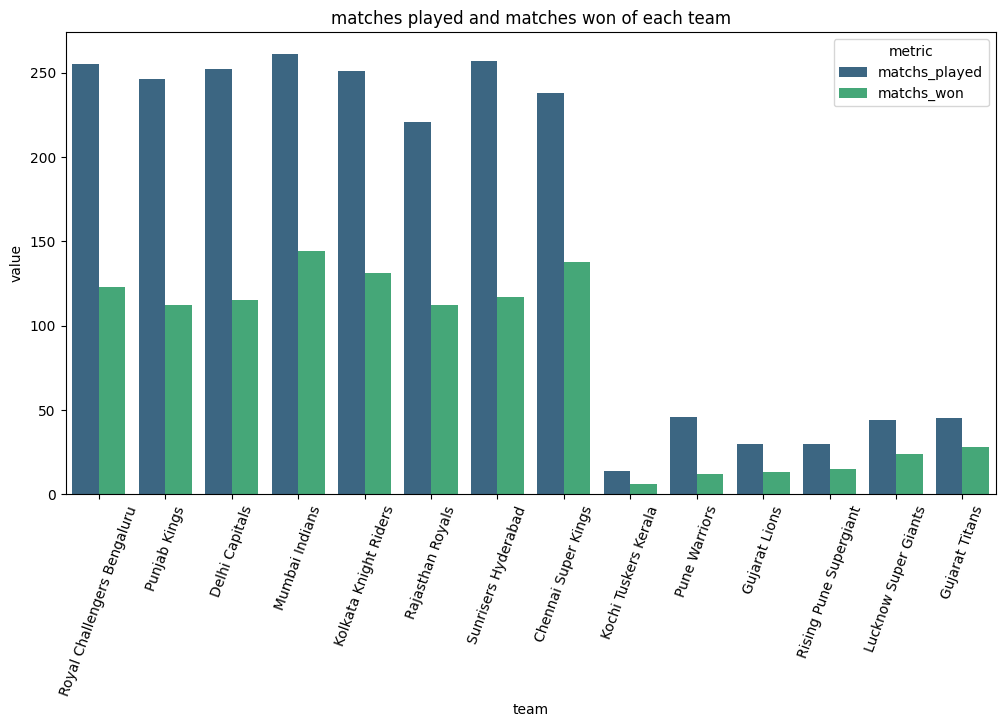

In [66]:
# plotting matches played & winning percentage

team_stats_melted = team_stats.melt(id_vars=['team_name'], value_vars=['matchs_played','matchs_won'],
                                    var_name='metric', value_name='value')

plt.figure(figsize=(12,6))
sns.barplot(x='team_name', y='value', hue='metric', data=team_stats_melted, palette='viridis')
plt.title('matches played and matches won of each team')
plt.xlabel('team')
plt.ylabel('value')
plt.xticks(rotation=70)
plt.legend(title='metric')
plt.show()

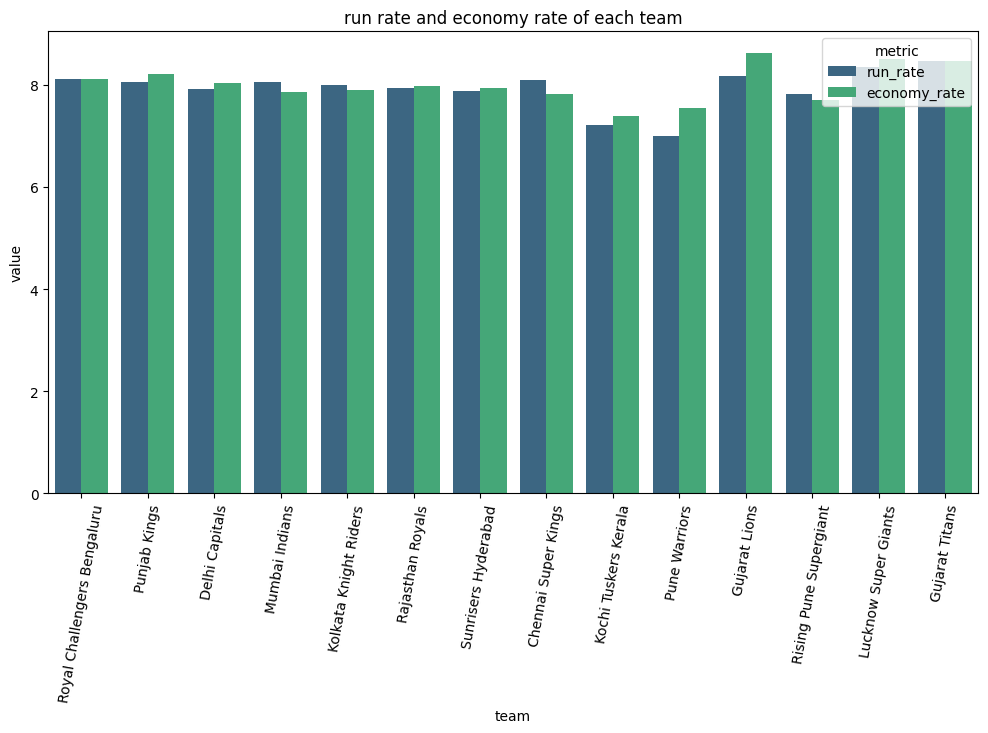

In [67]:
# plotting run rate & economy rate

team_stats_melted = team_stats.melt(id_vars=['team_name'], value_vars=['run_rate','economy_rate'],
                                    var_name='metric', value_name='value')

plt.figure(figsize=(12,6))
sns.barplot(x='team_name', y='value', hue='metric', data=team_stats_melted, palette='viridis')
plt.title('run rate and economy rate of each team')
plt.xlabel('team')
plt.ylabel('value')
plt.xticks(rotation=80)
plt.legend(title='metric')
plt.show()

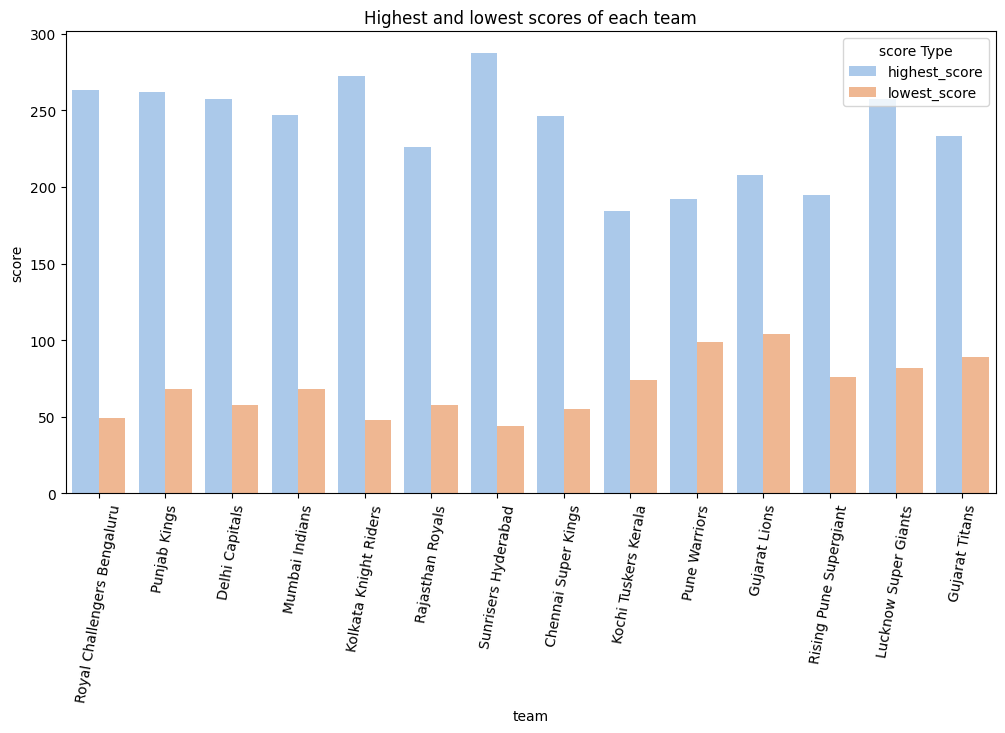

In [68]:
# plotting highest and lowest scores

plt.figure(figsize=(12,6))
team_stats_melted = team_stats.melt(id_vars=['team_name'], value_vars=['highest_score','lowest_score'],
                                    var_name='score Type', value_name='Score')

sns.barplot(x='team_name', y='Score', hue='score Type', data=team_stats_melted, palette='pastel')
plt.title('Highest and lowest scores of each team')
plt.xlabel('team')
plt.ylabel('score')
plt.xticks(rotation=80)
plt.show()

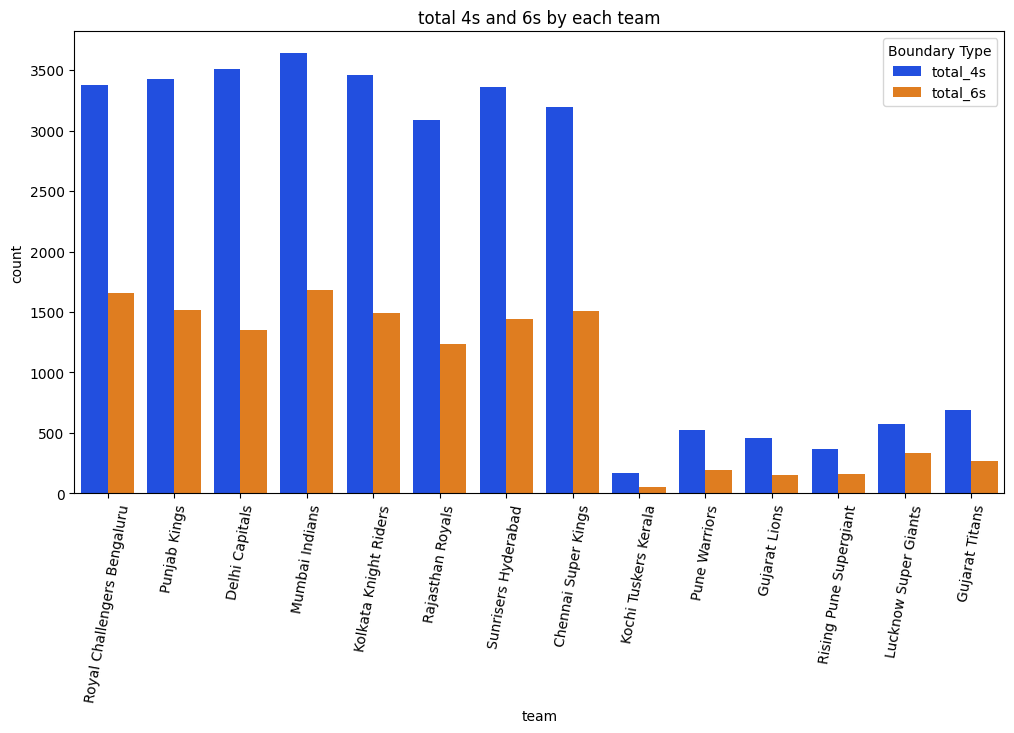

In [69]:
# plotting total 4s and 6s

plt.figure(figsize=(12, 6))
team_stats_melted = team_stats.melt(id_vars=['team_name'], value_vars=['total_4s','total_6s'],
                                    var_name='Boundary Type', value_name='count')
sns.barplot(x='team_name', y='count', hue='Boundary Type', data=team_stats_melted, palette='bright')
plt.title('total 4s and 6s by each team')
plt.xlabel('team')
plt.ylabel('count')
plt.xticks(rotation=80)
plt.show()

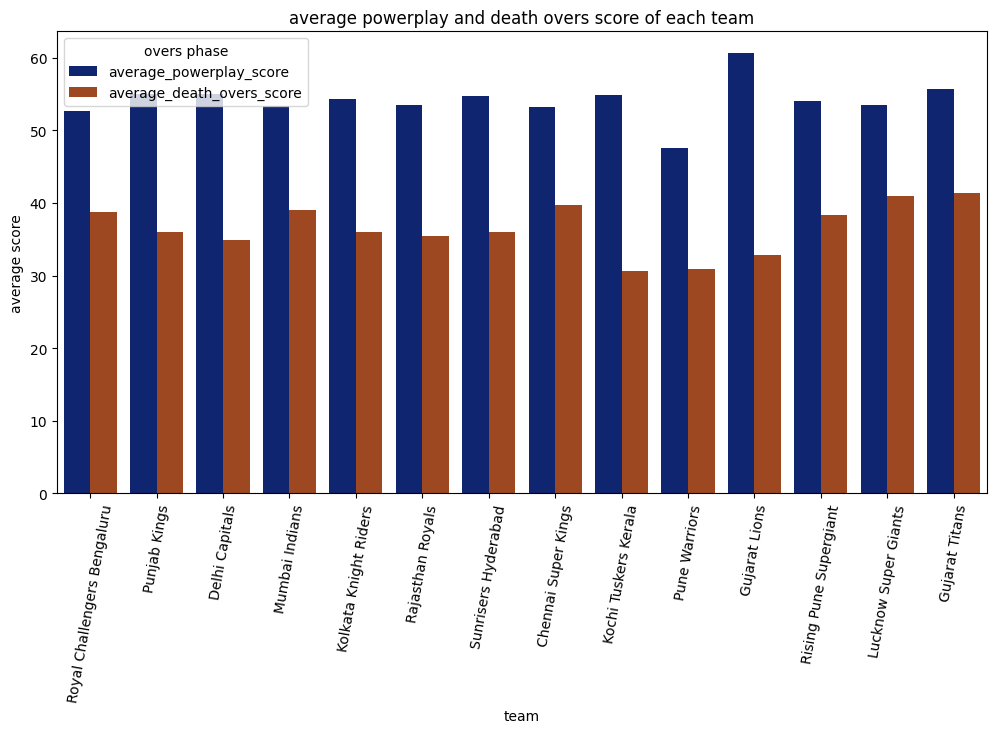

In [70]:
# plotting average powerplay and death overs score

plt.figure(figsize=(12, 6))
team_stats_melted = team_stats.melt(id_vars=['team_name'], value_vars=['average_powerplay_score', 'average_death_overs_score'],
                                    var_name='overs phase', value_name='average score')
sns.barplot(x='team_name', y='average score', hue='overs phase', data=team_stats_melted, palette='dark')
plt.title('average powerplay and death overs score of each team')
plt.xlabel('team')
plt.ylabel('average score')
plt.xticks(rotation=80)
plt.show()

Player Performance


In [71]:
players.head()

,matchs,balls_faced,innings,runs,0s,1s,2s,3s,4s,6s,...,batting_avg,batting_strike_rate,balls_throw,wickets,overs,runs_conceded,bowling_econ,bowling_strike_rate,catches,man_of_the_match_count
A Ashish Reddy,28.0,196.0,2.0,280.0,61.0,83.0,20.0,1.0,16.0,15.0,...,18.67,142.86,270.0,18.0,45.0,396.0,8.80,15.00,8.0,0.0
A Badoni,35.0,505.0,2.0,634.0,183.0,201.0,48.0,3.0,46.0,24.0,...,24.38,125.54,25.0,2.0,4.0,36.0,9.00,12.50,13.0,0.0
A Chandila,12.0,7.0,1.0,4.0,3.0,4.0,0.0,0.0,0.0,0.0,...,4.00,57.14,234.0,11.0,39.0,242.0,6.21,21.27,2.0,1.0
A Chopra,6.0,75.0,2.0,53.0,45.0,21.0,2.0,0.0,7.0,0.0,...,10.60,70.67,0.0,0.0,0.0,0.0,0.00,0.00,2.0,0.0
A Choudhary,5.0,20.0,2.0,25.0,4.0,13.0,1.0,0.0,1.0,1.0,...,12.50,125.00,108.0,5.0,18.0,144.0,8.00,21.60,0.0,0.0


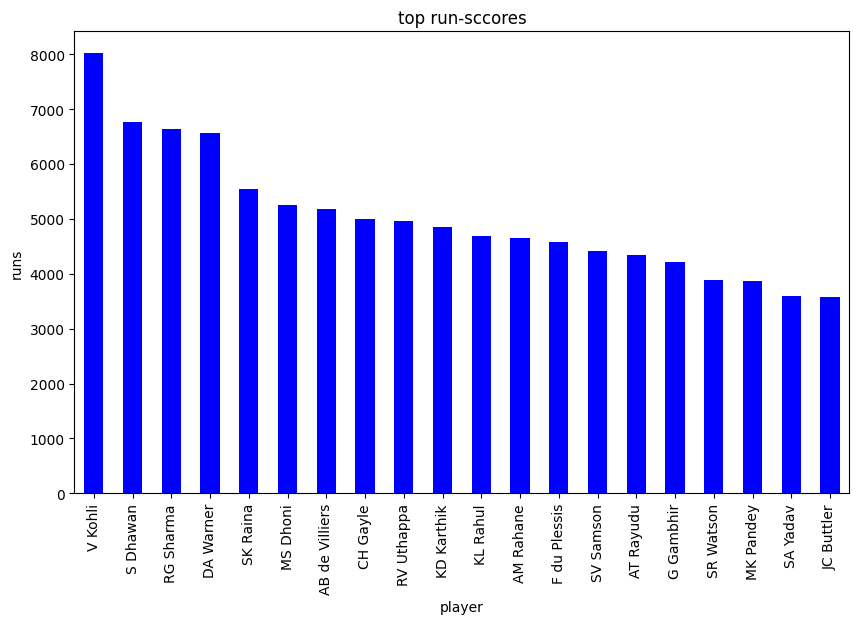

In [72]:
plt.figure(figsize=(10,6))
top_run_scorers = players['runs'].nlargest(20)
top_run_scorers.plot(kind='bar', color='blue')
plt.xlabel('player')
plt.ylabel('runs')
plt.title('top run-sccores')
plt.show()

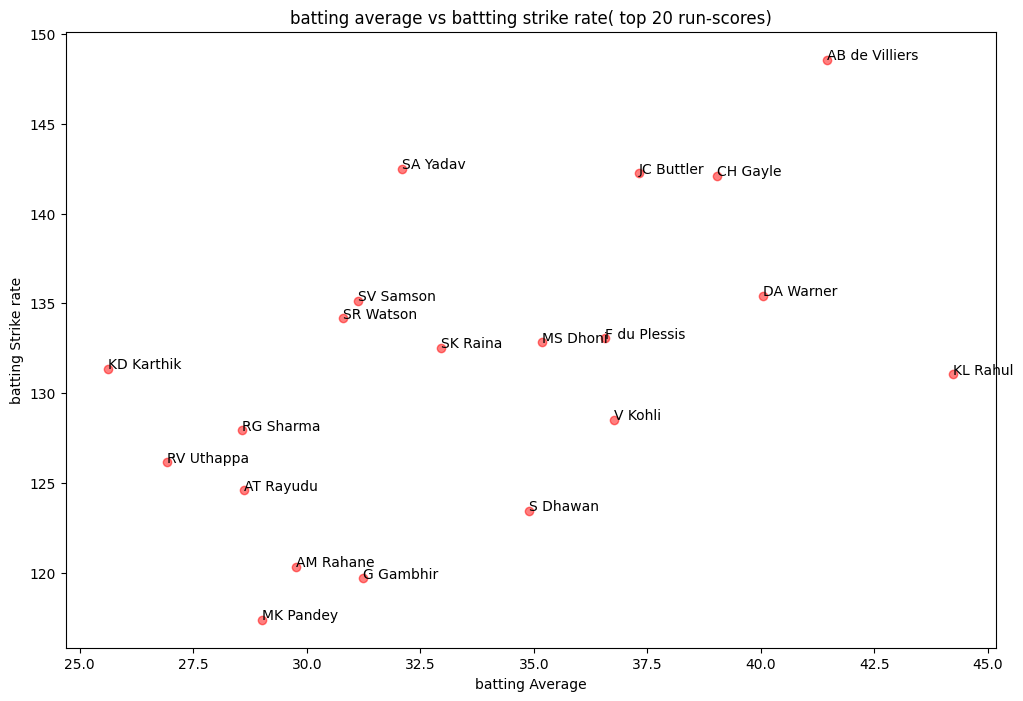

In [73]:
# get the top 20 ru-scores

top_run_scores = players.nlargest(20,'runs')

#plotting batting average vs batting strike rate for the top 20 run-scores

plt.figure(figsize=(12,8))
plt.scatter(top_run_scores['batting_avg'], top_run_scores['batting_strike_rate'], color='red', alpha=0.5)
plt.xlabel('batting Average')
plt.ylabel('batting Strike rate')
plt.title('batting average vs battting strike rate( top 20 run-scores)')

# annotate each point with the player name

for i, player in top_run_scores.iterrows():
  plt.annotate(player.name, (player['batting_avg'], player['batting_strike_rate']))


plt.show()

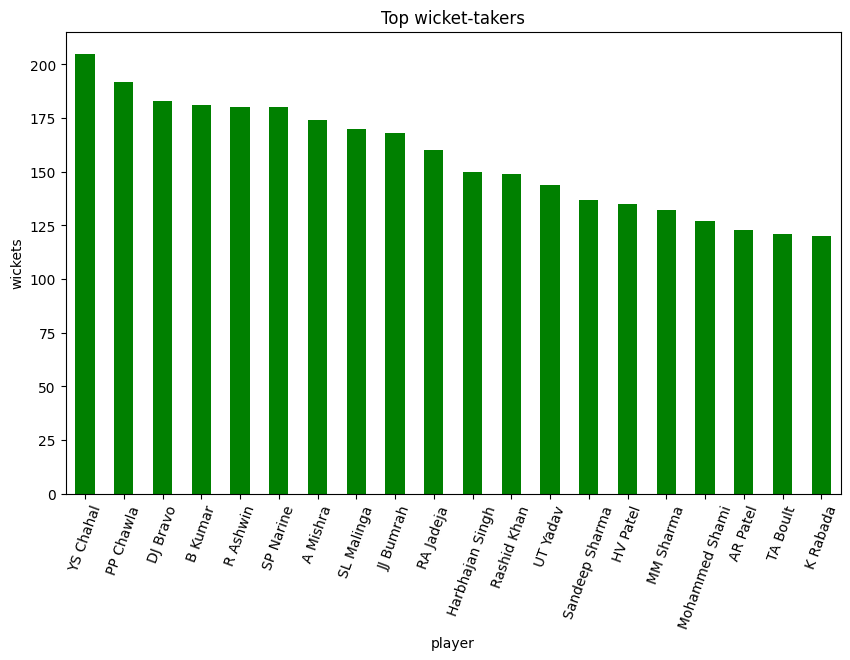

In [74]:
# plotting top wicket-takers

plt.figure(figsize=(10,6))
top_wicket_takers = players['wickets'].nlargest(20)
top_wicket_takers.plot(kind='bar', color='green')
plt.xlabel('player')
plt.ylabel('wickets')
plt.title('Top wicket-takers')
plt.xticks(rotation=70)
plt.show()

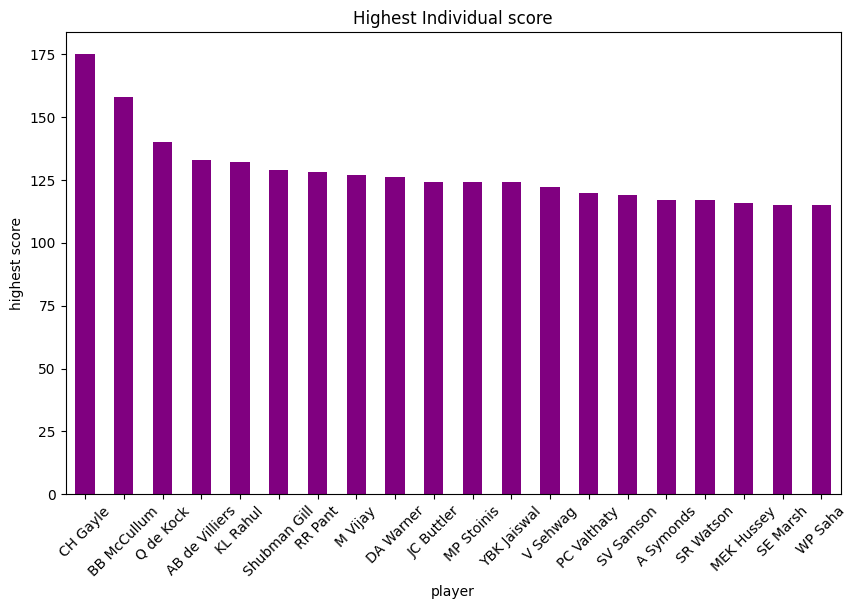

In [75]:
# plotting top highest individual scores

plt.figure(figsize=(10,6))
highest_scores = players['highest_score'].nlargest(20)
highest_scores.plot(kind='bar', color='purple')
plt.xlabel('player')
plt.ylabel('highest score')
plt.title('Highest Individual score')
plt.xticks(rotation=45)
plt.show()

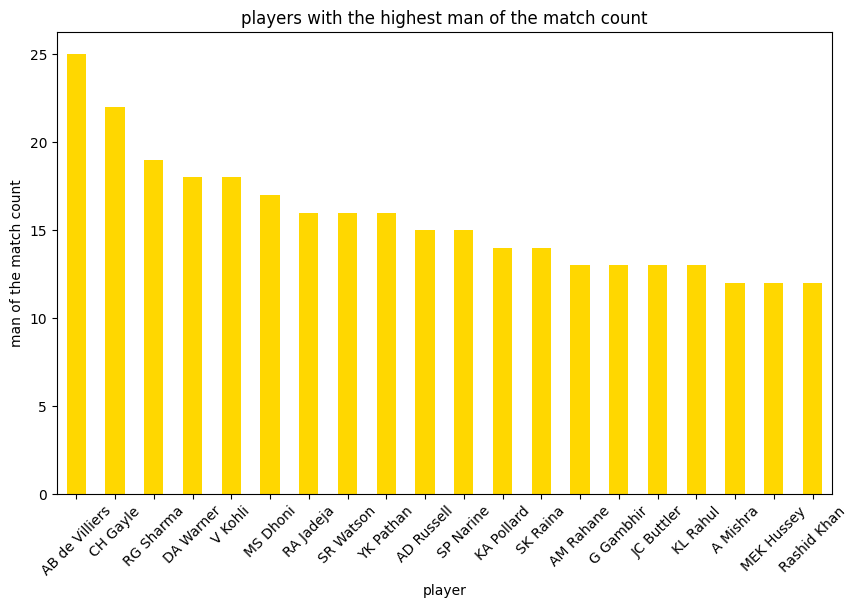

In [76]:
# Man of the match count

plt.figure(figsize=(10,6))
top_mom_players = players['man_of_the_match_count'].nlargest(20)
top_mom_players.plot(kind='bar', color='gold')
plt.xlabel('player')
plt.ylabel('man of the match count')
plt.title("players with the highest man of the match count")
plt.xticks(rotation=45)
plt.show()

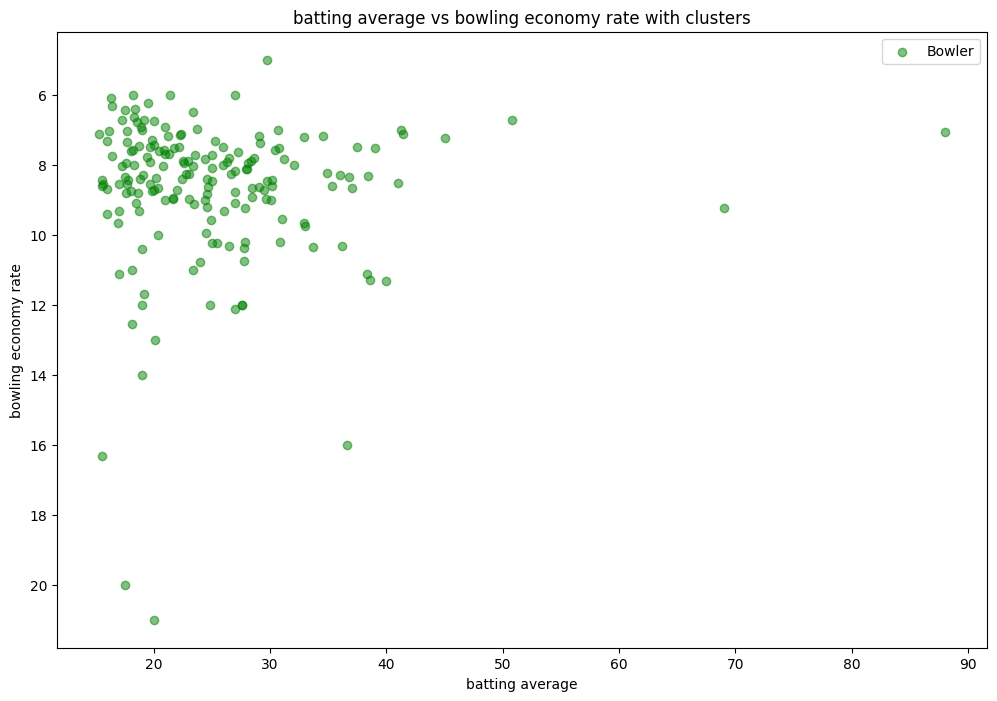

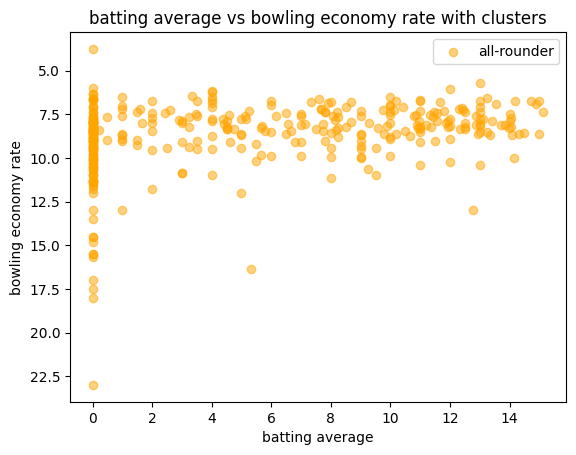

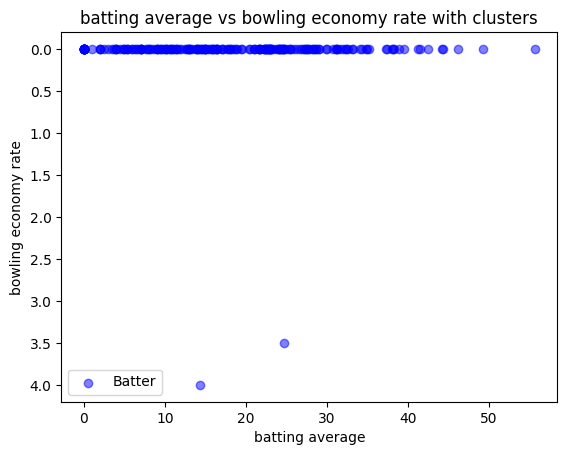

In [77]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# copy the DataFrame

players_copy = players.copy()

players_copy = players_copy[['bowling_econ','batting_avg']]

# check for NaN or infinite values

players_copy = players_copy.replace([float('inf'), -float('inf')], pd.NA)   # replace inf with NaN
players_copy = players_copy.dropna()    # Drop rows with NaN values

# standardize the data

scaler = StandardScaler()
scaled_features = scaler.fit_transform(players_copy)

# apply K-Means Clustering

num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=0)
clusters = kmeans.fit_predict(scaled_features);

# add the cluster column to the copied dataframe

players_copy['clusters'] = clusters

players = players.join(players_copy['clusters'], how='left', rsuffix='_cluster')

#Define cluster labels and colors

cluster_labels = {0:'Batter', 1:'Bowler', 2:'all-rounder'}
colors = {'Batter': 'Blue', 'Bowler':'Green', 'all-rounder':'orange'}

#map cluster labels to the clusters in the DateFrame

players['cluster'] = players['clusters'].map(cluster_labels)

# check for NaN values in the 'cluster' column

#print(players['cluster'].isna().sum())

#plotting batting average va bowling ecoonomy rate with clusters

plt.figure(figsize=(12,8))

#ensure no NaN values in 'Cluster' column before plotting
players_no_nan = players.dropna(subset=['cluster'])

for clust in players_no_nan['cluster'].unique():
  subset = players_no_nan[players_no_nan['cluster'] == clust]
  plt.scatter(subset['batting_avg'], subset['bowling_econ'],
              color=colors[clust], label=clust, alpha=0.5)

  plt.xlabel('batting average')
  plt.ylabel('bowling economy rate')
  plt.title('batting average vs bowling economy rate with clusters')
  plt.gca().invert_yaxis()   # invert y-axis to show better economy rates higher up
  plt.legend()
  plt.show()

Seasonal Analysis

In [78]:
# calculate average runs per match per season

seasonal_runs = matchs.groupby('season').agg({'target_runs':'mean'}).reset_index()
seasonal_runs.columns = ['season', 'average_runs']
seasonal_runs

,season,average_runs
0,2007/08,159.775862
1,2009,148.807018
2,2009/10,165.783333
3,2011,154.041667
4,2012,158.540541
5,2013,156.894737
6,2014,162.383333
7,2015,164.706897
8,2016,160.783333
9,2017,165.406780


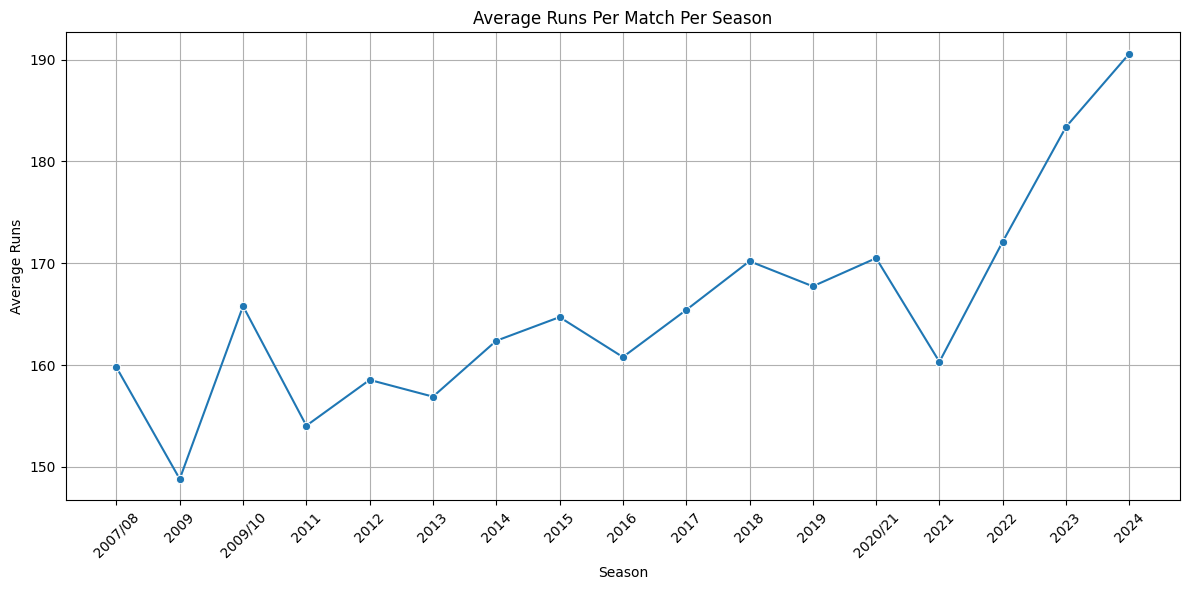

In [79]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='season', y='average_runs', data=seasonal_runs, marker='o')
plt.title('Average Runs Per Match Per Season')
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

wineer prediction model

In [80]:
deliveries = deliveries.copy()
matchs = matchs.copy()

In [81]:
inning_scores = deliveries.groupby(['match_id', 'inning'])['total_runs'].sum().reset_index()
inning_scores = inning_scores[inning_scores['inning']==1]
inning_scores.head()

,match_id,inning,total_runs
0,335982,1,222
2,335983,1,240
4,335984,1,129
6,335985,1,165
8,335986,1,110


In [82]:
inning_scores['target'] = inning_scores['total_runs'] + 1
inning_scores.head()

,match_id,inning,total_runs,target
0,335982,1,222,223
2,335983,1,240,241
4,335984,1,129,130
6,335985,1,165,166
8,335986,1,110,111


In [83]:
matchs.rename(columns={'id':'match_id'}, inplace=True)
matchs.head()

,match_id,season,city,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,...,super_over,method,umpire1,umpire2,dates,year,month,day,season_start,season_end
0,335982,2007/08,Bangalore,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,...,N,NaN,Asad Rauf,RE Koertzen,2008-04-18,2008,4,18,2007,2008
1,335983,2007/08,Chandigarh,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,...,N,NaN,MR Benson,SL Shastri,2008-04-19,2008,4,19,2007,2008
2,335984,2007/08,Delhi,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,...,N,NaN,Aleem Dar,GA Pratapkumar,2008-04-19,2008,4,19,2007,2008
3,335985,2007/08,Mumbai,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,...,N,NaN,SJ Davis,DJ Harper,2008-04-20,2008,4,20,2007,2008
4,335986,2007/08,Kolkata,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,...,N,NaN,BF Bowden,K Hariharan,2008-04-20,2008,4,20,2007,2008


In [84]:
matchs = matchs.merge(inning_scores[['match_id','target']], on='match_id')
matchs.head()

,match_id,season,city,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,...,method,umpire1,umpire2,dates,year,month,day,season_start,season_end,target
0,335982,2007/08,Bangalore,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,...,NaN,Asad Rauf,RE Koertzen,2008-04-18,2008,4,18,2007,2008,223
1,335983,2007/08,Chandigarh,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,...,NaN,MR Benson,SL Shastri,2008-04-19,2008,4,19,2007,2008,241
2,335984,2007/08,Delhi,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,...,NaN,Aleem Dar,GA Pratapkumar,2008-04-19,2008,4,19,2007,2008,130
3,335985,2007/08,Mumbai,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,...,NaN,SJ Davis,DJ Harper,2008-04-20,2008,4,20,2007,2008,166
4,335986,2007/08,Kolkata,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,...,NaN,BF Bowden,K Hariharan,2008-04-20,2008,4,20,2007,2008,111


In [85]:
matchs['team1'].unique()

array(['Royal Challengers Bengaluru', 'Punjab Kings', 'Delhi Capitals',
       'Mumbai Indians', 'Kolkata Knight Riders', 'Rajasthan Royals',
       'Sunrisers Hyderabad', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Lucknow Super Giants', 'Gujarat Titans'],
      dtype=object)

In [86]:
# mapping dictionary for old names to srtandardized names

team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI punjab': 'Punjab Kinbgs',
    'Rising Pune Supergiant': 'Pune Warriors',
    'Rising Pune Supergiants': 'Pune Warriors',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Royal Chaallengers Bengaluru': 'Royal Challengers Bangalore',
}

team_columns = ['winner','team1','team2','toss_winner']

#replace the team names in team columns

matchs[team_columns]= matchs[team_columns].replace(team_name_mapping)

In [87]:
matchs['city'].unique()

array(['Bangalore', 'Chandigarh', 'Delhi', 'Mumbai', 'Kolkata', 'Jaipur',
       'Hyderabad', 'Chennai', 'Cape Town', 'Port Elizabeth', 'Durban',
       'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Kochi', 'Indore', 'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi',
       'Abu Dhabi', nan, 'Rajkot', 'Kanpur', 'Bengaluru', 'Dubai',
       'Sharjah', 'Navi Mumbai', 'Lucknow', 'Guwahati', 'Mohali'],
      dtype=object)

In [88]:
#replace city names

map_city_names={'Bengaluru':'Bangalore'}
matchs['city'] = matchs['city'].replace(map_city_names)

matchs['city'].unique()

array(['Bangalore', 'Chandigarh', 'Delhi', 'Mumbai', 'Kolkata', 'Jaipur',
       'Hyderabad', 'Chennai', 'Cape Town', 'Port Elizabeth', 'Durban',
       'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Kochi', 'Indore', 'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi',
       'Abu Dhabi', nan, 'Rajkot', 'Kanpur', 'Dubai', 'Sharjah',
       'Navi Mumbai', 'Lucknow', 'Guwahati', 'Mohali'], dtype=object)

In [89]:
matchs.isnull().sum()

,0
match_id,0
season,0
city,51
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0


In [90]:
# extracting only selected columns

matchs = matchs[['match_id','season','city','team1','team2','winner','target']].dropna()
matchs.head()

,match_id,season,city,team1,team2,winner,target
0,335982,2007/08,Bangalore,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,223
1,335983,2007/08,Chandigarh,Punjab Kings,Chennai Super Kings,Chennai Super Kings,241
2,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130
3,335985,2007/08,Mumbai,Mumbai Indians,Royal Challengers Bengaluru,Royal Challengers Bengaluru,166
4,335986,2007/08,Kolkata,Kolkata Knight Riders,Sunrisers Hyderabad,Kolkata Knight Riders,111


In [91]:
matchs.isnull().sum()

,0
match_id,0
season,0
city,0
team1,0
team2,0
winner,0
target,0


In [92]:
# Team that will play in 2025 season

team_2025 = [
    'chennai super kings',
    'Delhi Capitals',
    'Gujarat Titans',
    'Kolkata Knight Riders',
    'Lucknow Super Giants',
    'Mumbai Indians',
    'Punjab Kings',
    'Rajasthan Royals',
    'Royal Challengers Bangalore',
    'Sunrisers Hyderabad',
]

#extracting only the selected teams

matchs = matchs[matchs['team1'].isin(team_2025)]
mathcs = matchs[matchs['team2'].isin(team_2025)]


matchs.head()

,match_id,season,city,team1,team2,winner,target
1,335983,2007/08,Chandigarh,Punjab Kings,Chennai Super Kings,Chennai Super Kings,241
2,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130
3,335985,2007/08,Mumbai,Mumbai Indians,Royal Challengers Bengaluru,Royal Challengers Bengaluru,166
4,335986,2007/08,Kolkata,Kolkata Knight Riders,Sunrisers Hyderabad,Kolkata Knight Riders,111
5,335987,2007/08,Jaipur,Rajasthan Royals,Punjab Kings,Rajasthan Royals,167


In [93]:

# Replace the team names in the 'batting team' columns_to_handle_missing
deliveries['batting_team'] = deliveries['batting_team'].replace(team_name_mapping)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_name_mapping)

deliveries = deliveries[deliveries['batting_team'].isin(team_2025)]
deliveries = deliveries[deliveries['bowling_team'].isin(team_2025)]
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
473,335984,1,Rajasthan Royals,Delhi Capitals,0,1,T Kohli,GD McGrath,YK Pathan,0,0,0,NaN,0,NaN,NaN,NaN
474,335984,1,Rajasthan Royals,Delhi Capitals,0,2,T Kohli,GD McGrath,YK Pathan,0,0,0,NaN,0,NaN,NaN,NaN
475,335984,1,Rajasthan Royals,Delhi Capitals,0,3,T Kohli,GD McGrath,YK Pathan,0,0,0,NaN,0,NaN,NaN,NaN
476,335984,1,Rajasthan Royals,Delhi Capitals,0,4,T Kohli,GD McGrath,YK Pathan,0,1,1,wides,0,NaN,NaN,NaN
477,335984,1,Rajasthan Royals,Delhi Capitals,0,5,T Kohli,GD McGrath,YK Pathan,0,0,0,NaN,0,NaN,NaN,NaN


In [94]:
#merge to the final datasets

final = matchs.merge(deliveries, on='match_id')
final.head()


,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,1,Rajasthan Royals,Delhi Capitals,...,GD McGrath,YK Pathan,0,0,0,NaN,0,NaN,NaN,NaN
1,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,1,Rajasthan Royals,Delhi Capitals,...,GD McGrath,YK Pathan,0,0,0,NaN,0,NaN,NaN,NaN
2,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,1,Rajasthan Royals,Delhi Capitals,...,GD McGrath,YK Pathan,0,0,0,NaN,0,NaN,NaN,NaN
3,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,1,Rajasthan Royals,Delhi Capitals,...,GD McGrath,YK Pathan,0,1,1,wides,0,NaN,NaN,NaN
4,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,1,Rajasthan Royals,Delhi Capitals,...,GD McGrath,YK Pathan,0,0,0,NaN,0,NaN,NaN,NaN


In [95]:
# get only second inninng matchs

final = final[final['inning'] == 2]
final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
122,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,MM Patel,V Sehwag,0,0,0,NaN,0,NaN,NaN,NaN
123,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,MM Patel,V Sehwag,0,0,0,NaN,0,NaN,NaN,NaN
124,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,MM Patel,V Sehwag,0,0,0,NaN,0,NaN,NaN,NaN
125,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,MM Patel,V Sehwag,0,0,0,NaN,0,NaN,NaN,NaN
126,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,MM Patel,V Sehwag,4,0,4,NaN,0,NaN,NaN,NaN


In [96]:
# add ' currennt_score'

final.loc[:, 'current_score'] =  final.groupby('match_id')['total_runs'].cumsum()
final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score
122,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,V Sehwag,0,0,0,NaN,0,NaN,NaN,NaN,0
123,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,V Sehwag,0,0,0,NaN,0,NaN,NaN,NaN,0
124,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,V Sehwag,0,0,0,NaN,0,NaN,NaN,NaN,0
125,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,V Sehwag,0,0,0,NaN,0,NaN,NaN,NaN,0
126,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,V Sehwag,4,0,4,NaN,0,NaN,NaN,NaN,4


In [97]:
import numpy as np
# add 'runs_left'
final.loc[:, 'runs_left'] = np.where(final['target']-final['current_score']>=0, final['target']-final['current_score'], 0)
final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left
122,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,0,0,NaN,0,NaN,NaN,NaN,0,130
123,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,0,0,NaN,0,NaN,NaN,NaN,0,130
124,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,0,0,NaN,0,NaN,NaN,NaN,0,130
125,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,0,0,NaN,0,NaN,NaN,NaN,0,130
126,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,4,0,4,NaN,0,NaN,NaN,NaN,4,126


In [98]:
# add 'baalls_left'
final.loc[:, 'balls_left'] = np.where(120 - final['over']*6-final['ball']>=0, 120-final['over']*6-final['ball'], 0)
final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left
122,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,0,NaN,0,NaN,NaN,NaN,0,130,119
123,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,0,NaN,0,NaN,NaN,NaN,0,130,118
124,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,0,NaN,0,NaN,NaN,NaN,0,130,117
125,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,0,NaN,0,NaN,NaN,NaN,0,130,116
126,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,4,NaN,0,NaN,NaN,NaN,4,126,115


In [99]:
# add 'wickets_left'

final.loc[:,'wickets_left'] = 10-final.groupby('match_id')['is_wicket'].cumsum()
final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets_left
122,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,NaN,0,NaN,NaN,NaN,0,130,119,10
123,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,NaN,0,NaN,NaN,NaN,0,130,118,10
124,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,NaN,0,NaN,NaN,NaN,0,130,117,10
125,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,NaN,0,NaN,NaN,NaN,0,130,116,10
126,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,4,NaN,0,NaN,NaN,NaN,4,126,115,10


In [100]:
# calculate 'current_runn_rate'

final['current_run_rate'] = np.where(
    120 - final['balls_left']>0,
    (final['current_score'] *6)/(120 - final['balls_left']),
    0
)

# calculate 'required_run_rate'

final['required_run_rate'] = np.where(
    final['balls_left']>0,
    (final['runs_left']*6)/final['balls_left'],
    np.where(final['runs_left']>0, 1e6,0)
)

final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets_left,current_run_rate,required_run_rate
122,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,NaN,NaN,NaN,0,130,119,10,0.0,6.554622
123,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,NaN,NaN,NaN,0,130,118,10,0.0,6.610169
124,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,NaN,NaN,NaN,0,130,117,10,0.0,6.666667
125,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,NaN,NaN,NaN,0,130,116,10,0.0,6.724138
126,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,0,NaN,NaN,NaN,4,126,115,10,4.8,6.573913


In [101]:
def result(row):
  return 1 if row['batting_team'] == row['winner'] else 0

final['result'] = final.apply(result, axis=1)
final.head()

,match_id,season,city,team1,team2,winner,target,inning,batting_team,bowling_team,...,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets_left,current_run_rate,required_run_rate,result
122,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,NaN,NaN,NaN,0,130,119,10,0.0,6.554622,1
123,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,NaN,NaN,NaN,0,130,118,10,0.0,6.610169,1
124,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,NaN,NaN,NaN,0,130,117,10,0.0,6.666667,1
125,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,NaN,NaN,NaN,0,130,116,10,0.0,6.724138,1
126,335984,2007/08,Delhi,Delhi Capitals,Rajasthan Royals,Delhi Capitals,130,2,Delhi Capitals,Rajasthan Royals,...,NaN,NaN,NaN,4,126,115,10,4.8,6.573913,1


In [102]:
winning_pred = final[['season','batting_team','bowling_team','city','runs_left','balls_left','wickets_left','current_run_rate','required_run_rate','target','result']]
winning_pred.head()

,season,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,current_run_rate,required_run_rate,target,result
122,2007/08,Delhi Capitals,Rajasthan Royals,Delhi,130,119,10,0.0,6.554622,130,1
123,2007/08,Delhi Capitals,Rajasthan Royals,Delhi,130,118,10,0.0,6.610169,130,1
124,2007/08,Delhi Capitals,Rajasthan Royals,Delhi,130,117,10,0.0,6.666667,130,1
125,2007/08,Delhi Capitals,Rajasthan Royals,Delhi,130,116,10,0.0,6.724138,130,1
126,2007/08,Delhi Capitals,Rajasthan Royals,Delhi,126,115,10,4.8,6.573913,130,1


In [103]:
winning_pred['batting_team'].unique()

array(['Delhi Capitals', 'Kolkata Knight Riders', 'Rajasthan Royals',
       'Mumbai Indians', 'Sunrisers Hyderabad', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants'], dtype=object)

In [104]:
season_2024 = winning_pred[winning_pred['season'] == '2024']
other_season = winning_pred[winning_pred['season']!='2024']

#define X and Y for both datasets

X_train_23 = other_season.drop(['result','season'], axis=1)
Y_train_23 = other_season['result']

X_train_test_23 = season_2024.drop(['result','season'], axis=1)
Y_test_24 = season_2024['result']

#verify the splits

print("training set size:", X_train_23.shape, Y_train_23.shape)
print("the set size:", X_train_test_23.shape, Y_test_24.shape)

training set size: (54511, 9) (54511,)
the set size: (5044, 9) (5044,)


In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# column Transformer

trf = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), [ 'batting_team', 'bowling_team', 'city']),
    ('num', StandardScaler(), ['runs_left', 'balls_left', 'wickets_left','current_run_rate', 'required_run_rate', 'target'])
], remainder= 'passthrough')

In [106]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

# Define the pipeline with the XGBoost classifier

Pipe = Pipeline(steps=[
    ('preprocessor', trf),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

#Hyperparameter tuning

param_distributions = {
    'classifier__n_estimators': randint(100, 301),  #range [100, 300]
    'classifier__max_depth': randint(3, 10),        #range [3, 9]
    'classifier__learning_rate': uniform(0.01, 0.19), #range [0.01, 0.2]
    'classifier__subsample': uniform(0.5, 0.5),     #range [0.5, 1.0]
    'classifier__colsample_bytree': uniform(0.3, 0.7)  # range [0.3, 1.0]
}


# Perform randomized search

random_search = RandomizedSearchCV(Pipe, param_distributions, n_iter=100, cv=5, scoring='accuracy', random_state=42, n_jobs=-1, verbose=2)
random_search.fit(X_train_23, Y_train_23)


#best model

best_model_1 = random_search.best_estimator_
best_params_1 = random_search.best_params_
best_score_1 = random_search.best_score_

#print the results

print(f"best parameters: {best_params_1}")
print(f"best cross-validation score: {best_score_1}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:13:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


best parameters: {'classifier__colsample_bytree': np.float64(0.38125084835484135), 'classifier__learning_rate': np.float64(0.018740501984133025), 'classifier__max_depth': 3, 'classifier__n_estimators': 193, 'classifier__subsample': np.float64(0.9277302920055036)}
best cross-validation score: 0.7617172699140313


In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

pipe = Pipeline(steps=[
    ('preprocessor', trf),
    ('classifier', RandomForestClassifier())
])


#Hyperparameter tuning

param_distributions = {
    'classifier__n_estimators': randint(100, 301),   #range [100, 300]
    'classifier__max_depth': randint(10, 31),        # range [10, 30]
    'classifier__min_samples_split': randint(2, 11)    # range [2,10]
}


# perform randomized search

random_search = RandomizedSearchCV(pipe, param_distributions, n_iter=100, scoring='accuracy', random_state=42, n_jobs=-1, verbose=2)
random_search.fit(X_train_23, Y_train_23)


# best model

best_model_2 = random_search.best_estimator_
best_params_2 = random_search.best_params_
best_score_2 = random_search.best_score_



#print  the results

print(f"best parameters: {best_params_2}")
print(f"best cross-validation score: {best_score_2}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
best parameters: {'classifier__max_depth': 12, 'classifier__min_samples_split': 4, 'classifier__n_estimators': 247}
best cross-validation score: 0.758745380223092


In [114]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# create a voting classifier combining these models

final_model = VotingClassifier(estimators=[
    ('xgb', best_model_1),
    ('rnd', best_model_2),
], voting='soft')


#train the voting classifier on the train dataset

final_model.fit(X_train_23, Y_train_23)

#evaluate the performance on a test set

Y_pred = final_model.predict(X_train_test_23)
print("accuracy on test set:", accuracy_score(Y_test_24, Y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:35:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy on test set: 0.767248215701824


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [116]:
final_model.predict(X_train_test_23)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([1, 0, 1, ..., 1, 1, 1])

In [118]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test_24, Y_pred))
print(confusion_matrix(Y_test_24, Y_pred))

              precision    recall  f1-score   support

           0       0.74      0.86      0.80      2686
           1       0.81      0.66      0.73      2358

    accuracy                           0.77      5044
   macro avg       0.78      0.76      0.76      5044
weighted avg       0.77      0.77      0.76      5044

[[2319  367]
 [ 807 1551]]


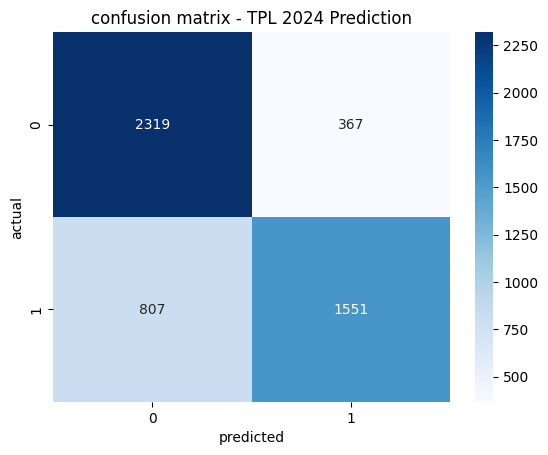

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(Y_test_24, Y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix - TPL 2024 Prediction")
plt.show()

In [122]:
final_model.predict_proba(X_train_test_23)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([[0.49459335, 0.50540665],
       [0.51111174, 0.48888826],
       [0.48824655, 0.51175345],
       ...,
       [0.11054785, 0.88945215],
       [0.11054785, 0.88945215],
       [0.11259788, 0.88740212]])

In [124]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#predict on the test set
y_pred = final_model.predict(X_train_test_23)

#predict probabilities if needed
y_pred_proba = final_model.predict_proba(X_train_test_23)

#calculate and print accuracy

accuracy = accuracy_score(Y_test_24, y_pred)
print(f"accuracy: {accuracy:.4f}")

#calculate and print other metrics if needed

precision = precision_score(Y_test_24, y_pred, average='weighted')
recall = recall_score(Y_test_24, y_pred, average='weighted')
f1 = f1_score(Y_test_24, y_pred, average='weighted')

print(f"precision: {precision:.4f}")
print(f"recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")


# print a detailed classification report

print('\nClassification report:')
print(classification_report(Y_test_24, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


accuracy: 0.7672
precision: 0.7731
recall: 0.7672
F1 score: 0.7641

Classification report:
              precision    recall  f1-score   support

           0       0.74      0.86      0.80      2686
           1       0.81      0.66      0.73      2358

    accuracy                           0.77      5044
   macro avg       0.78      0.76      0.76      5044
weighted avg       0.77      0.77      0.76      5044



In [126]:
# sample input

l = [['Royal Challengers Bangalore', 'Mumbai Indians', 'Mumbai', 108, 49, 6,10,6.5,200]]

columns = ['batting_team','bowling_team','city','runs_left','balls_left','wickets_left','current_run_rate','required_run_rate','target']

season_25 = pd.DataFrame(l, columns=columns)

final_model.predict_proba(season_25)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([[0.32779285, 0.67220715]])